In [1]:
import numpy as np
import pandas as pd

# Simulate discontinuous (jumpy) stock prices for a distressed stock
# Put this cell at index 0 in your notebook.

import matplotlib.pyplot as plt

def simulate_distressed_stock(
    S0=100.0,
    mu=0.02,
    sigma=0.35,
    jump_lambda=1.0,        # expected jumps per year (high for distressed)
    jump_mean=-0.5,         # mean of log-jump (negative => downward jumps)
    jump_std=0.8,           # volatility of log-jump
    large_shock_prob=0.02,  # daily prob of an extra large downward gap
    large_shock_frac=0.5,   # fraction drop on large shock (0.5 => -50%)
    halt_rate=0.1,          # expected number of trading halts per year
    halt_mean_dur=2,        # mean halt duration in trading steps
    T=1.0,                  # years
    N=252,                  # steps (trading days)
    num_paths=5,
    seed=None
):
    """
    Returns a DataFrame of simulated prices (num_paths columns) indexed by fractional time (0..T).
    Model: Merton jump-diffusion with negative-biased jumps, additional rare large downward gaps,
    and random trading halts (set to NaN for the duration).
    """
    rng = np.random.default_rng(seed)
    dt = T / N
    times = np.linspace(0.0, T, N+1)
    S = np.zeros((num_paths, N+1))
    S[:, 0] = S0

    for t in range(1, N+1):
        # diffusion part
        Z = rng.normal(size=num_paths)
        diffusion = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

        # Poisson jumps: number of jumps in dt
        counts = rng.poisson(jump_lambda * dt, size=num_paths)
        jumps = np.ones(num_paths)

        # when count>0, total log-jump ~ Normal(count*jump_mean, sqrt(count)*jump_std)
        inds = counts > 0
        if inds.any():
            sum_mean = counts[inds] * jump_mean
            sum_std = np.sqrt(counts[inds]) * jump_std
            jumps[inds] = np.exp(rng.normal(loc=sum_mean, scale=sum_std, size=inds.sum()))

        # occasional large downward gap (overnight or catastrophic news)
        large_shock = rng.uniform(size=num_paths) < (large_shock_prob * dt)
        if large_shock.any():
            # multiply by (1 - fraction) to drop price
            jumps[large_shock] *= (1.0 - large_shock_frac)

        S[:, t] = S[:, t - 1] * diffusion * jumps

    # Introduce random trading halts: set price to NaN during halt durations
    if halt_rate > 0:
        expected_halts = rng.poisson(lam=halt_rate * T, size=num_paths)
        for i in range(num_paths):
            n_halts = expected_halts[i]
            for _ in range(n_halts):
                # choose start step uniformly, duration from geometric/exponential approx
                start = rng.integers(1, N + 1)
                dur = max(1, int(rng.exponential(scale=halt_mean_dur)))
                end = min(N, start + dur - 1)
                S[i, start:end + 1] = np.nan

    cols = [f"path_{i}" for i in range(num_paths)]
    df = pd.DataFrame(S.T, index=times, columns=cols)
    return df


In [2]:
df = simulate_distressed_stock(
    S0=50,
    mu=-0.10,
    sigma=0.5,
    jump_lambda=2.0,
    jump_mean=-0.7,
    jump_std=0.9,
    large_shock_prob=0.03,
    large_shock_frac=0.6,
    halt_rate=0.2,
    halt_mean_dur=3,
    T=1,
    N=252,
    num_paths=4,
    seed=42
)

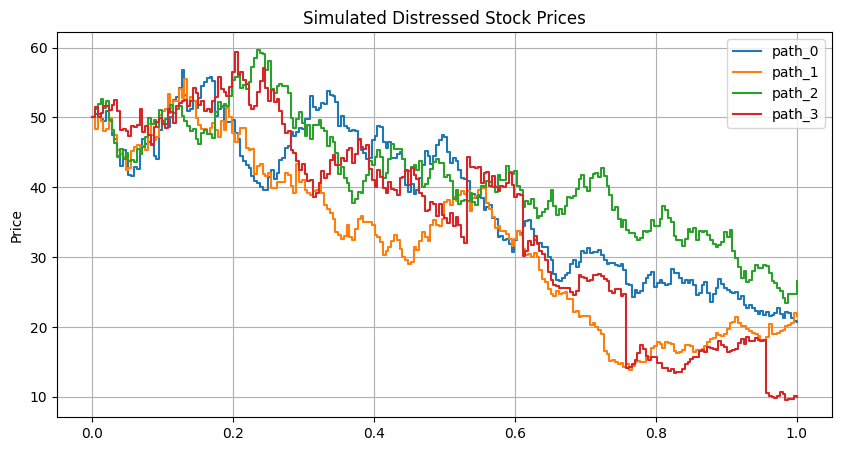

In [7]:
ax = df.plot(figsize=(10, 5), drawstyle='steps-post', title="Simulated Distressed Stock Prices")
ax.set_ylabel("Price")
plt.grid(True)
plt.show()

In [5]:
# Calibrate sigma from observed (or simulated) prices and visualise
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional


def calibrate_sigma_from_prices(prices: pd.Series, trading_days: int = 252) -> float:
    """Estimate annualized sigma (volatility) from a price series.

    Uses the standard deviation of daily log returns and annualizes by sqrt(trading_days).

    Args:
        prices: pd.Series of prices indexed by date or step.
        trading_days: number of trading days per year (default 252).

    Returns:
        Annualized volatility (sigma).
    """
    if prices.size < 2:
        raise ValueError("Need at least two price points to estimate volatility")
    # compute log returns, drop NaN
    lr = np.log(prices).diff().dropna()
    daily_std = float(lr.std(ddof=0))
    annualized_sigma = daily_std * np.sqrt(trading_days)
    return annualized_sigma


def capture_and_visualise_distressed(prices: pd.Series,
                                     S0: Optional[float] = None,
                                     mu: float = 0.0,
                                     jump_lambda: float = 2.0,
                                     jump_mean: float = -0.7,
                                     jump_std: float = 0.9,
                                     large_shock_prob: float = 0.03,
                                     large_shock_frac: float = 0.6,
                                     halt_rate: float = 0.2,
                                     halt_mean_dur: float = 3,
                                     trading_days: int = 252,
                                     num_sim_paths: int = 4,
                                     seed: Optional[int] = None):
    """Calibrate sigma from `prices`, simulate distressed paths using calibrated sigma and plot overlay.

    The calibration simply estimates sigma from daily log-returns and annualizes it. The function then
    calls the `simulate_distressed_stock` (assumed to be defined in the notebook) to produce sample paths
    and overlays them on the provided prices for visual comparison.

    Args:
        prices: pd.Series of observed prices (index can be numeric or dates).
        S0: initial price for simulation (if None, uses first price in `prices`).
        mu, jump_*, large_shock_*, halt_*: model parameters forwarded to the simulator.
        trading_days: number of trading days per year used for annualization and simulation N.
        num_sim_paths: number of simulated paths to generate.
        seed: random seed for reproducible simulation.

    Returns:
        dict with calibrated_sigma and simulated DataFrame under keys 'sigma' and 'sim'.
    """
    if S0 is None:
        S0 = float(prices.dropna().iloc[0])

    # Calibrate sigma from observed prices
    sigma = calibrate_sigma_from_prices(prices, trading_days=trading_days)

    # Build simulation horizon to match observed length
    # If index is numeric fractional time (0..T with N+1 points), derive N from length
    T = 1.0
    N = len(prices) - 1
    if N <= 0:
        raise ValueError("Prices series must contain at least 2 observations")

    # Call simulator defined earlier in the notebook. It expects T, N, num_paths etc.
    try:
        sim_df = simulate_distressed_stock(S0=S0, mu=mu, sigma=sigma, jump_lambda=jump_lambda,
                                           jump_mean=jump_mean, jump_std=jump_std,
                                           large_shock_prob=large_shock_prob, large_shock_frac=large_shock_frac,
                                           halt_rate=halt_rate, halt_mean_dur=halt_mean_dur,
                                           T=T, N=N, num_paths=num_sim_paths, seed=seed)
    except NameError:
        raise RuntimeError("simulate_distressed_stock not found in this notebook - please define it before using this helper")

    # Plot observed series and simulated paths
    plt.figure(figsize=(12, 6))
    # If prices index is not a simple numeric range, plot against a range to align with sim_df index
    x_obs = np.arange(len(prices))
    plt.plot(x_obs, prices.values, label="Observed", color="black", linewidth=2)

    for col in sim_df.columns:
        plt.plot(np.arange(len(sim_df)), sim_df[col].values, label=f"Sim {col}", alpha=0.8)

    plt.title(f"Observed vs Simulated Distressed Paths (calibrated sigma={sigma:.3f})")
    plt.xlabel("Step")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.show()

    return {"sigma": sigma, "sim": sim_df}


# Example usage (uncomment and run):
# result = capture_and_visualise_distressed(df['path_0'])
# print("Calibrated sigma:", result['sigma'])


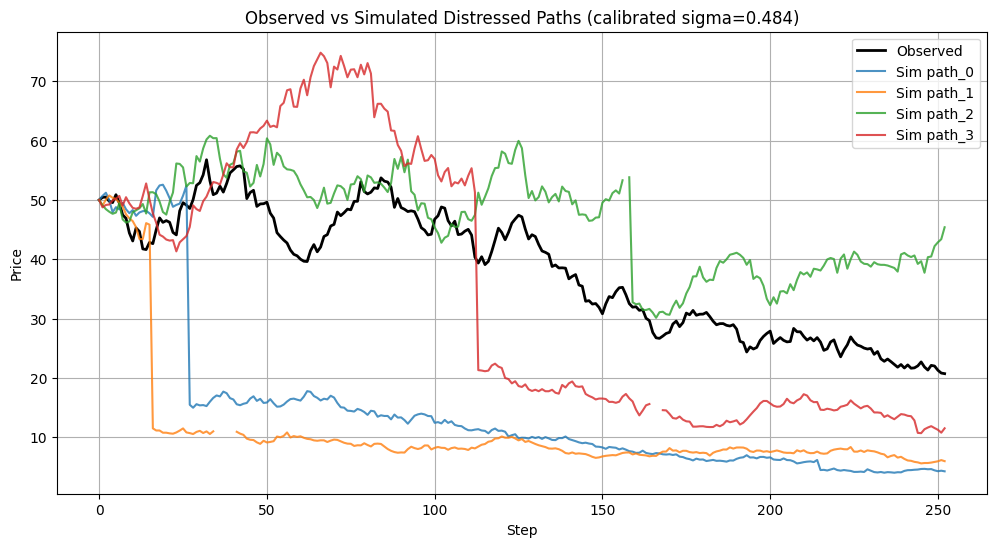

Calibrated sigma: 0.4838733476864837


In [6]:
result = capture_and_visualise_distressed(df['path_0'])
print("Calibrated sigma:", result['sigma'])

## nan_policy: semantics and recommendations


This cell explains the `nan_policy` option used by the Monte Carlo valuation helper `mc_price_expected_terminal`.


- **drop** (default)


  - Description: Discard any simulated paths whose terminal price is NaN and compute the expectation only over surviving paths.


  - When to use: Good when NaNs indicate incomplete or invalid simulations (data corruption), or you want to avoid making assumptions about missing values.


  - Effect: Reduces effective sample size (effective_paths). Can upward- or downward-bias estimates if NaNs are informative.




- **ffill**


  - Description: Forward-fill NaNs along each path (use the most recent observed price) then take the last value.


  - When to use: Appropriate when NaNs arise from short trading halts and the last-observed price is a reasonable proxy for the terminal value.


  - Effect: Preserves path counts and often gives more stable estimates; assumes price would have remained near the last observed value.




- **last**


  - Description: Use the last non-NaN observation for each path (similar to `ffill`, but explicitly picks the last observed point rather than forward-filling the full DataFrame).


  - When to use: Similar to `ffill`; useful when you want the simplest last-known-value imputation without modifying the full DataFrame.




- **zero**


  - Description: Replace NaN terminal prices with `0.0`.


  - When to use: Very conservative choice (e.g., when a halt implies a catastrophic loss or default); may be appropriate for worst-case stress testing.


  - Effect: Can dramatically lower expected payoffs and is typically a lower bound.




Recommendations


- Run sensitivity checks across multiple `nan_policy` choices and report the range. This helps understand how much missing-terminal behavior affects valuation.


- For practical valuations where halts are temporary and you trust market microstructure, prefer `ffill` or `last`.


- For conservative risk provisioning or when NaNs indicate serious failure/default, use `zero` or `drop` depending on context.




Quick examples




```python


# default (drop)


res = mc_price_expected_terminal(..., nan_policy='drop')


# forward-fill last-known


res = mc_price_expected_terminal(..., nan_policy='ffill')


# pessimistic zero-impute


res = mc_price_expected_terminal(..., nan_policy='zero')


```




Always document which policy you used when reporting MC prices.

In [13]:
# Monte Carlo valuation helpers for distressed asset transformations
import numpy as np
import pandas as pd
from typing import Callable, Optional, Dict


def simulate_under_risk_neutral(r: float,
                                 q: float,
                                 S0: float,
                                 sigma: float,
                                 jump_lambda: float = 1.0,
                                 jump_mean: float = -0.5,
                                 jump_std: float = 0.8,
                                 large_shock_prob: float = 0.02,
                                 large_shock_frac: float = 0.5,
                                 halt_rate: float = 0.1,
                                 halt_mean_dur: float = 2,
                                 T: float = 1.0,
                                 N: int = 252,
                                 num_paths: int = 5000,
                                 seed: Optional[int] = None) -> pd.DataFrame:
    """Simulate distressed stock paths under the risk-neutral measure.

    We set the diffusion drift mu = r - q so that discounted asset prices are martingales (ignoring jumps' market price of risk).
    This is an approximation — if jumps have a market price of risk, a proper change of measure is required. For
    exploratory valuation this is commonly used.

    Returns a DataFrame of simulated prices (N+1 rows, columns path_0..path_{num_paths-1}).
    """
    mu_rn = r - q
    sim = simulate_distressed_stock(S0=S0, mu=mu_rn, sigma=sigma, jump_lambda=jump_lambda,
                                    jump_mean=jump_mean, jump_std=jump_std,
                                    large_shock_prob=large_shock_prob, large_shock_frac=large_shock_frac,
                                    halt_rate=halt_rate, halt_mean_dur=halt_mean_dur,
                                    T=T, N=N, num_paths=num_paths, seed=seed)
    return sim


def mc_price_expected_terminal(S0: float,
                               r: float,
                               q: float = 0.0,
                               sigma: float = 0.5,
                               payoff: Optional[Callable[[np.ndarray], np.ndarray]] = None,
                               num_paths: int = 5000,
                               T: float = 1.0,
                               N: int = 252,
                               simulate_kwargs: Optional[Dict] = None,
                               seed: Optional[int] = None,
                               nan_policy: str = "drop") -> Dict:
    """Monte Carlo price of a transformed payoff on the distressed asset.

    - If `payoff` is None, the identity payoff is used (i.e., price the stock itself at T: payoff(S)=S).
    - The function simulates under the risk-neutral drift (mu = r - q) and returns the discounted expectation.

    NaN handling (nan_policy):
      * 'drop'  - drop simulated paths with NaN terminal prices (default, previous behaviour)
      * 'ffill' - forward-fill along each path and take the last value (uses last observed price before halt)
      * 'last'  - take the last non-NaN observation per path (similar to ffill, but computed differently)
      * 'zero'  - treat NaN terminal prices as 0.0

    Returns a dict with keys: "price" (discounted expectation), "std_err", "raw" (array of discounted payoffs),
    and diagnostic metrics like survival_prob and mean_terminal.
    """
    if simulate_kwargs is None:
        simulate_kwargs = {}

    sim = simulate_under_risk_neutral(r=r, q=q, S0=S0, sigma=sigma, T=T, N=N, num_paths=num_paths, seed=seed, **simulate_kwargs)
    # terminal prices (last row) - will be processed according to nan_policy

    nan_policy = str(nan_policy).lower()
    if nan_policy not in {"drop", "ffill", "last", "zero"}:
        raise ValueError(f"Unsupported nan_policy: {nan_policy}")

    if nan_policy == "drop":
        terminal = sim.iloc[-1].values
    elif nan_policy == "ffill":
        # forward-fill along time axis then take last row; keeps last-known price if any
        sim_filled = sim.ffill(axis=0)
        terminal = sim_filled.iloc[-1].values
    elif nan_policy == "last":
        # last non-NaN value per column (path); if a column is all NaN, result will be NaN
        last_vals = []
        for col in sim.columns:
            col_series = sim[col].dropna()
            if col_series.size == 0:
                last_vals.append(np.nan)
            else:
                last_vals.append(col_series.iloc[-1])
        terminal = np.array(last_vals)
    else:  # 'zero'
        terminal = sim.fillna(0.0).iloc[-1].values

    # mask of valid terminal prices (non-NaN)
    mask = ~np.isnan(terminal)
    effective_paths = int(mask.sum())

    if effective_paths == 0:
        raise RuntimeError("All simulated terminal prices are NaN (after applying nan_policy)")

    terminal_valid = terminal[mask]

    if payoff is None:
        payoffs = terminal_valid
    else:
        payoffs = payoff(terminal_valid)

    discounted = np.exp(-r * T) * payoffs
    price = float(np.mean(discounted))
    std_err = float(np.std(discounted, ddof=1) / np.sqrt(discounted.size))

    result = {
        "price": price,
        "std_err": std_err,
        "num_paths": int(num_paths),
        "effective_paths": effective_paths,
        "mean_terminal": float(np.mean(terminal_valid)),
        "median_terminal": float(np.median(terminal_valid)),
        "survival_prob": float(mask.mean()),
        "nan_policy": nan_policy,
        "raw": discounted,
    }
    return result


# Convenience payoff helpers

def payoff_call(K: float) -> Callable[[np.ndarray], np.ndarray]:
    return lambda S: np.maximum(S - K, 0.0)


def payoff_put(K: float) -> Callable[[np.ndarray], np.ndarray]:
    return lambda S: np.maximum(K - S, 0.0)


# Example: price expected discounted terminal stock value and a deep OTM put as proxy for distress tail
# Uncomment and run in the notebook environment:
# res_stock = mc_price_expected_terminal(S0=50, r=0.02, q=0.0, sigma=0.5, num_paths=2000, T=1.0, N=252, seed=123, nan_policy='ffill')
# print('Expected discounted stock price (MC):', res_stock['price'], 'std_err:', res_stock['std_err'])
# res_put = mc_price_expected_terminal(S0=50, r=0.02, q=0.0, sigma=0.5, payoff=payoff_put(20), num_paths=2000, T=1.0, N=252, seed=123, nan_policy='last')
# print('Put price (proxy for distress tail):', res_put['price'])

In [14]:
# Detect distress-related spikes/drops and visualize them
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict, Optional


def detect_distress_events(prices: pd.Series,
                           window: int = 20,
                           z_thresh: float = 3.0,
                           pct_thresh: float = 0.15,
                           min_duration: int = 1,
                           direction: str = "down",
                           return_positions: bool = False) -> Tuple[pd.DataFrame, pd.Series]:
    """Identify spike/drop events in a price series that indicate distress-like moves.

    Strategy:
      - Compute simple percent returns r_t = P_t / P_{t-1} - 1
      - Compute rolling mean/std of returns over `window` and flag points where the return deviates
        from the local mean by >= `z_thresh` standard deviations OR abs(return) >= pct_thresh.
      - direction: 'down' (drops only), 'up' (spikes only), 'both' (either)
      - Group contiguous flagged points into events and summarize each event.

    Args:
      prices: pd.Series of prices (index can be datetime or numeric)
      window: integer rolling window for local mean/std
      z_thresh: z-score threshold for abnormal moves
      pct_thresh: absolute percent-change threshold (e.g., 0.15 = 15%)
      min_duration: minimum number of contiguous flagged steps to consider an event
      direction: 'down'|'up'|'both'
      return_positions: if True, include integer start_pos/end_pos (positional indices) in the events DataFrame

    Returns:
      events: DataFrame with one row per detected event with columns:
        start_idx, end_idx, start_date, end_date, duration, max_drop_pct, max_spike_pct, cum_return,
        and optionally start_pos/end_pos when return_positions=True
      mask: boolean Series aligned with `prices` True where an abnormal move was flagged
    """
    if not isinstance(prices, pd.Series):
        prices = pd.Series(prices)

    # percent returns
    ret = prices.pct_change()

    # rolling stats
    roll_mean = ret.rolling(window=window, min_periods=1).mean()
    roll_std = ret.rolling(window=window, min_periods=1).std(ddof=0)

    # z-score based flags (guard against zero std)
    z = (ret - roll_mean) / roll_std.replace(0, np.nan)
    z_flag = z.abs() >= z_thresh

    # absolute percent threshold
    pct_flag = ret.abs() >= pct_thresh

    # combine flags
    combined = z_flag | pct_flag

    if direction == "down":
        combined = combined & (ret <= 0)
    elif direction == "up":
        combined = combined & (ret >= 0)
    elif direction == "both":
        pass
    else:
        raise ValueError("direction must be one of 'down','up','both'")

    combined = combined.fillna(False)

    # group contiguous True segments
    groups = (combined != combined.shift(1)).cumsum()
    events = []

    # helper to get positional index
    index_list = list(prices.index)
    index_to_pos = {idx: i for i, idx in enumerate(index_list)}

    for g, grp in combined[combined].groupby(groups):
        idxs = grp.index
        if idxs.size == 0:
            continue
        start_idx = idxs[0]
        end_idx = idxs[-1]
        duration = int((combined.loc[start_idx:end_idx].sum()))
        if duration < min_duration:
            continue
        # compute summary stats for the event
        segment_rets = ret.loc[start_idx:end_idx].dropna()
        try:
            cum_return = (prices.loc[start_idx:end_idx].iloc[-1] / prices.loc[start_idx] - 1)
        except Exception:
            cum_return = float(segment_rets.add(1).prod() - 1) if not segment_rets.empty else 0.0
        max_drop = float(segment_rets.min()) if not segment_rets.empty else 0.0
        max_spike = float(segment_rets.max()) if not segment_rets.empty else 0.0

        event = {
            "start_idx": start_idx,
            "end_idx": end_idx,
            "start_date": start_idx,
            "end_date": end_idx,
            "duration": duration,
            "max_drop_pct": max_drop,
            "max_spike_pct": max_spike,
            "cum_return": cum_return,
        }

        if return_positions:
            # map to integer positions; if index not found, use NaN
            event["start_pos"] = index_to_pos.get(start_idx, np.nan)
            event["end_pos"] = index_to_pos.get(end_idx, np.nan)

        events.append(event)

    events_df = pd.DataFrame(events)

    return events_df, combined


def plot_distress_events(prices: pd.Series, events: pd.DataFrame, mask: pd.Series, figsize=(12, 5)) -> None:
    """Plot price series and mark detected distress events.

    - prices: pd.Series
    - events: DataFrame as returned by detect_distress_events
    - mask: boolean Series alignment with prices indicating flagged points
    """
    plt.figure(figsize=figsize)
    plt.plot(prices.index, prices.values, label="Price", color="black")

    # mark flagged points
    flagged = prices[mask]
    if not flagged.empty:
        plt.scatter(flagged.index, flagged.values, color="red", marker="x", label="flagged")

    # annotate events
    if events is not None and not events.empty:
        for _, row in events.iterrows():
            s = row["start_idx"]
            e = row["end_idx"]
            # plot vertical span
            try:
                plt.axvspan(s, e, color="red", alpha=0.1)
            except Exception:
                # fallback when indices are positional
                try:
                    plt.axvspan(prices.index[row.get("start_pos")], prices.index[row.get("end_pos")], color="red", alpha=0.1)
                except Exception:
                    pass
            # annotate max drop
            try:
                xpos = prices.index[row.get("start_pos")] if "start_pos" in row and not pd.isna(row.get("start_pos")) else s
                plt.text(xpos,
                         prices.max() * 0.95,
                         f"dur={row['duration']} max_drop={row['max_drop_pct']:.2%}",
                         fontsize=8,
                         color="red")
            except Exception:
                pass

    plt.title("Price series with detected distress events")
    plt.xlabel("Index")
    plt.ylabel("Price")
    plt.grid(True)
    plt.legend()
    plt.show()


# Example usage:
# events, mask = detect_distress_events(df['path_0'], window=20, z_thresh=3.0, pct_thresh=0.15, direction='down', return_positions=True)
# print(events)
# plot_distress_events(df['path_0'], events, mask)


Running nan_policy=drop ...
policy=drop: price=41.8987, std_err=1.2210, effective_paths=1999
Running nan_policy=ffill ...
policy=ffill: price=41.8825, std_err=1.2205, effective_paths=2000
Running nan_policy=last ...
policy=last: price=41.8825, std_err=1.2205, effective_paths=2000
Running nan_policy=zero ...
policy=zero: price=41.8778, std_err=1.2206, effective_paths=2000

Summary:
  policy      price   std_err  effective_paths  survival_prob
0   drop  41.898706  1.221012             1999         0.9995
1  ffill  41.882468  1.220510             2000         1.0000
2   last  41.882468  1.220510             2000         1.0000
3   zero  41.877757  1.220582             2000         1.0000
policy=last: price=41.8825, std_err=1.2205, effective_paths=2000
Running nan_policy=zero ...
policy=zero: price=41.8778, std_err=1.2206, effective_paths=2000

Summary:
  policy      price   std_err  effective_paths  survival_prob
0   drop  41.898706  1.221012             1999         0.9995
1  ffill  41.8

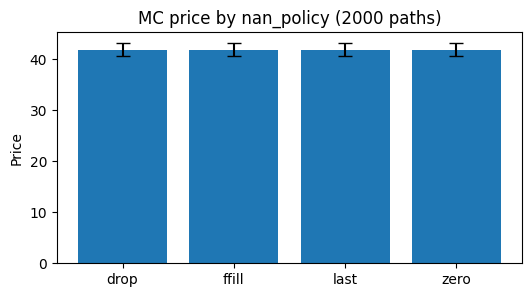

In [15]:
# Compare nan_policy choices for Monte Carlo valuation
policies = ['drop', 'ffill', 'last', 'zero']
results = {}

# set modest path count for quick comparison; increase num_paths for production
for p in policies:
    print(f"Running nan_policy={p} ...")
    res = mc_price_expected_terminal(S0=50, r=0.02, q=0.0, sigma=0.5, num_paths=2000, T=1.0, N=252, seed=123, nan_policy=p)
    results[p] = res
    print(f"policy={p}: price={res['price']:.4f}, std_err={res['std_err']:.4f}, effective_paths={res['effective_paths']}")

import pandas as pd
summary = pd.DataFrame([
    { 'policy': k, 'price': v['price'], 'std_err': v['std_err'], 'effective_paths': v['effective_paths'], 'survival_prob': v['survival_prob'] }
    for k, v in results.items()
])
print('\nSummary:')
print(summary)

# Optional: plot policy price comparison
plt.figure(figsize=(6,3))
plt.bar(summary['policy'], summary['price'], yerr=summary['std_err'], capsize=5)
plt.title('MC price by nan_policy (2000 paths)')
plt.ylabel('Price')
plt.show()


In [16]:
# Run detector across all simulated paths and summarise events per path
paths = [c for c in df.columns]
path_summaries = []

for col in paths:
    series = df[col]
    events, mask = detect_distress_events(series, window=20, z_thresh=3.0, pct_thresh=0.15, direction='down', return_positions=True)
    n_events = 0 if events is None or events.empty else len(events)
    mean_dur = events['duration'].mean() if n_events>0 else 0
    max_drop = events['max_drop_pct'].min() if n_events>0 else 0
    path_summaries.append({
        'path': col,
        'n_events': int(n_events),
        'mean_duration': float(mean_dur),
        'worst_drop': float(max_drop),
    })

import pandas as pd
summary_df = pd.DataFrame(path_summaries)
print(summary_df)

# Show events for the first path as example
if not summary_df.empty and summary_df.loc[0,'n_events']>0:
    evs, m = detect_distress_events(df[paths[0]], return_positions=True)
    print('\nEvents for', paths[0])
    print(evs)
    plot_distress_events(df[paths[0]], evs, m)


     path  n_events  mean_duration  worst_drop
0  path_0         0            0.0    0.000000
1  path_1         0            0.0    0.000000
2  path_2         0            0.0    0.000000
3  path_3         3            1.0   -0.432237
